Inflaton oscillation period: T_osc = 7.416299

Solving 200 chi_k modes ...


100%|██████████| 200/200 [13:56<00:00,  4.18s/it]


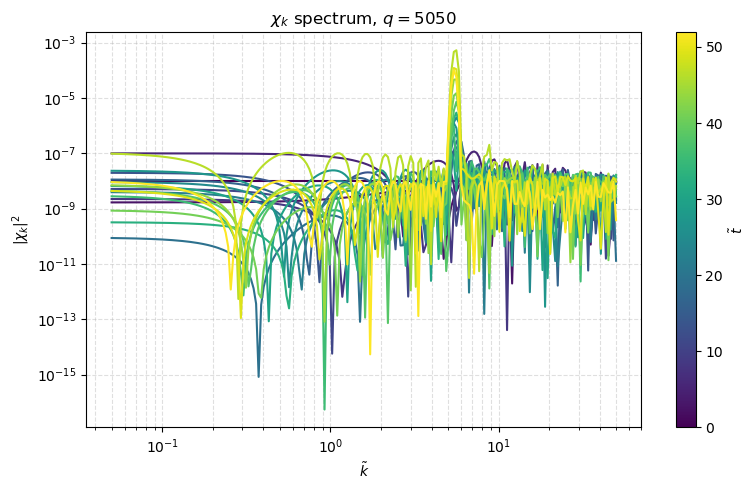


Computing Omega_GW for 100 k-values x 10 times ...


Computing Omega_GW:   0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_83400/108240598.py:265: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_tilde     = np.trapz(integrand_t, x=times_gw)
Computing Omega_GW:  88%|████████▊ | 878/1000 [15:53<02:12,  1.09s/it]


KeyboardInterrupt: 

In [1]:
"""
Gravitational waves from preheating: lambda*phi^4 + (g^2/2)*phi^2*chi^2
Flat spacetime (no Hubble expansion).

Inflaton potential:  V(phi) = (lambda/4) phi^4,  lambda = 1  (rescaled units)
EOM for phi:         phi'' = -phi^3
Perturbation EOM:    chi_k'' + [k^2 + q*phi^2(t)] chi_k = 0,   q = g^2/lambda

GW energy spectrum (Khlebnikov & Tkachev 1997 / Garcia-Bellido & Linde 1998):
  Omega_GW(k) = (k^3 / 4pi^4) * INT dp p^4 INT dx (1-x^2)^2 |I(k,p)|^2

where the time integral is:
  I(k, p, t_F) = INT_0^{t_F} dt  e^{i k t}  chi_p(t) * chi_{|k-p|}(t)

  and k3 = |k - p|,  x = cos(theta_kp).

All quantities are in rescaled (dimensionless) units where lambda = 1.
"""

import numpy as np
from scipy.integrate import quad, solve_ivp
from scipy.interpolate import interp1d
from tqdm import tqdm
from itertools import product
import matplotlib.pyplot as plt

# =============================================================================
# Parameters
# =============================================================================

# Inflaton background
phi0      = 1.0        # initial field value
phi_dot0  = 0.0        # initial field velocity

# chi mode initial conditions (classical / WKB seed)
chi_k0     = 1e-4
chi_dot_k0 = 0.0

# Resonance parameter  q = g^2 / lambda
q = 5050

# Integration parameters
Nt            = 1000   # time steps for background + chi ODEs
Tfin_Tosc     = 7      # run for this many inflaton oscillation periods

# k-grid for chi mode solutions
Nk_modes      = 200
k_min_mode    = 0.05
k_max_mode    = 50.0
k_modes       = np.geomspace(k_min_mode, k_max_mode, Nk_modes)

# Gauss-Legendre quadrature for the (p, x) double integral
Np = 100               # nodes in |p|
Nx = 100               # nodes in x = cos(theta)

# k-grid for the GW spectrum output
Nk_gw = 100
k_gw  = np.geomspace(k_min_mode, k_max_mode, Nk_gw)

# Number of output time snapshots for the GW spectrum
Nt_plot_gw = 10

# =============================================================================
# Inflaton oscillation period
# =============================================================================

def oscillation_period(phi0, phi_dot0):
    """
    Period of oscillation in the potential V = phi^4/4.
    T_osc = 4 * INT_0^{phi_max}  dphi / sqrt(2*(E - V(phi)))
    """
    E = 0.5 * phi_dot0**2 + 0.25 * phi0**4
    phi_max = (4.0 * E)**0.25

    def integrand(phi):
        dV = E - 0.25 * phi**4
        # Clamp to avoid sqrt of tiny negatives at the turning point
        return 1.0 / np.sqrt(2.0 * max(dV, 0.0)) if dV > 1e-14 else 0.0

    T_half, _ = quad(integrand, 0.0, phi_max, limit=200)
    return 4.0 * T_half

Tosc = oscillation_period(phi0, phi_dot0)
print(f"Inflaton oscillation period: T_osc = {Tosc:.6f}")

# =============================================================================
# Background inflaton
# =============================================================================

def solve_phi(phi0, phi_dot0, Nt, Tfin_Tosc, Tosc):
    """Solve phi'' = -phi^3 (EOM for V = phi^4/4 with lambda=1)."""
    Tfin  = Tfin_Tosc * Tosc
    t_eval = np.linspace(0.0, Tfin, Nt)

    def eom(t, y):
        phi, phi_dot = y
        return [phi_dot, -phi**3]

    sol = solve_ivp(
        eom, (0.0, Tfin), [phi0, phi_dot0],
        t_eval=t_eval, method='DOP853',
        rtol=1e-10, atol=1e-12        # tight tolerances for long runs
    )
    if not sol.success:
        raise RuntimeError(f"Background ODE failed: {sol.message}")
    return sol.t, sol.y[0]

t_phi, phi = solve_phi(phi0, phi_dot0, Nt=Nt, Tfin_Tosc=Tfin_Tosc, Tosc=Tosc)

phi_interp = interp1d(
    t_phi, phi,
    kind='cubic',
    bounds_error=False,
    fill_value="extrapolate"
)

# =============================================================================
# chi_k perturbation modes
# =============================================================================

def solve_chi(chi_k0, chi_dot_k0, phi_interp, k_val, q, Nt, Tfin_Tosc, Tosc):
    """
    Solve chi_k'' + [k^2 + q*phi^2(t)] chi_k = 0.
    """
    Tfin   = Tfin_Tosc * Tosc
    t_eval = np.linspace(0.0, Tfin, Nt)

    def eom(t, y):
        chi_k, chi_dot_k = y
        freq2 = k_val**2 + q * phi_interp(t)**2
        return [chi_dot_k, -freq2 * chi_k]

    sol = solve_ivp(
        eom, (0.0, Tfin), [chi_k0, chi_dot_k0],
        t_eval=t_eval, method='DOP853',
        rtol=1e-10, atol=1e-12,
        args=()   # phi_interp is captured via closure
    )
    if not sol.success:
        raise RuntimeError(f"chi ODE failed at k={k_val:.4f}: {sol.message}")
    return sol

print(f"\nSolving {Nk_modes} chi_k modes ...")
sol_chi_k = np.zeros((Nk_modes, Nt))
times     = None

for ik, k_val in enumerate(tqdm(k_modes)):
    sol = solve_chi(
        chi_k0, chi_dot_k0, phi_interp,
        k_val, q, Nt=Nt, Tfin_Tosc=Tfin_Tosc, Tosc=Tosc
    )
    sol_chi_k[ik, :] = sol.y[0]
    if ik == 0:
        times = sol.t

# =============================================================================
# Plot chi mode spectra at several times
# =============================================================================

Nt_plot     = 20
idx_plot    = np.linspace(0, Nt - 1, Nt_plot, dtype=int)
t_plot_arr  = times[idx_plot]

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis
norm = plt.Normalize(t_plot_arr.min(), t_plot_arr.max())

for it in idx_plot:
    ax.loglog(k_modes, np.abs(sol_chi_k[:, it])**2,
              color=cmap(norm(times[it])), lw=1.5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\tilde{t}$')
ax.set_xlabel(r'$\tilde{k}$')
ax.set_ylabel(r'$|\chi_k|^2$')
ax.set_title(rf'$\chi_k$ spectrum, $q={q}$')
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig("chi_spectrum.pdf")
plt.show()

# =============================================================================
# Interpolator: chi_k(t) as a function of k (log-space)
# =============================================================================

log_k_modes = np.log(k_modes)

chi_interp = interp1d(
    log_k_modes,
    sol_chi_k,          # shape (Nk_modes, Nt)
    axis=0,
    kind='linear',
    bounds_error=False,
    fill_value=0.0      # zero outside the k-grid (no power expected there)
)

def get_chi_array(k_query):
    """
    Return chi_k(t) as a 1-D array over all times via log-k interpolation.
    Returns zeros for k outside [k_min_mode, k_max_mode].
    """
    if k_query <= 0.0:
        return np.zeros(Nt)
    return np.asarray(chi_interp(np.log(k_query)))

# =============================================================================
# Gauss-Legendre quadrature nodes for the (p, x) integral
# =============================================================================

xi_p, w_p = np.polynomial.legendre.leggauss(Np)
p_lo, p_hi   = k_min_mode, k_max_mode
p_nodes      = 0.5 * (p_hi - p_lo) * xi_p + 0.5 * (p_hi + p_lo)
w_p_scaled   = 0.5 * (p_hi - p_lo) * w_p

xi_x, w_x = np.polynomial.legendre.leggauss(Nx)   # x in [-1, 1]

# =============================================================================
# GW spectrum computation
# =============================================================================

def compute_Omega_GW(k_val, t_F):
    """
    Compute Omega_GW(k, t_F) up to the overall (omega_*/M_pl)^2 prefactor.

    Omega_GW(k) = (k^3 / 4 pi^4)
                  * INT dp  p^4  INT_{-1}^{1} dx  (1 - x^2)^2  |I(k,p,t_F)|^2

    where
        I(k, p, t_F) = INT_0^{t_F} dt  exp(i k t)  chi_p(t)  chi_{|k-p|}(t)
        k3 = sqrt(k^2 + p^2 - 2 k p x)   (= |k - p|)

    The polarization kernel (1-x^2)^2 p^4 comes from the transverse-traceless
    projection of the stress tensor of a scalar field:
        Pi_{ij}^{TT} ~ p_i p_j (1 - x^2) / p^2  ... -> (p^2 (1-x^2))^2
    """

    mask        = times <= t_F
    times_gw    = times[mask]
    exp_ikt     = np.exp(1j * k_val * times_gw)   # shape (N_t_mask,)

    double_integral = 0.0

    for ip in range(Np):
        p    = p_nodes[ip]
        wp   = w_p_scaled[ip]

        X_p  = get_chi_array(p)[mask]             # chi_p(t),  shape (N_t_mask,)

        inner = 0.0

        for ix in range(Nx):
            x    = xi_x[ix]
            wx   = w_x[ix]

            # k3 = |k_vec - p_vec|
            k3_sq = k_val**2 + p**2 - 2.0 * k_val * p * x
            k3    = np.sqrt(max(k3_sq, 0.0))

            X_k3  = get_chi_array(k3)[mask]       # chi_{k3}(t), shape (N_t_mask,)

            # Time integral: I(k, p, t_F) with trapezoidal rule
            integrand_t = exp_ikt * X_p * X_k3
            I_tilde     = np.trapz(integrand_t, x=times_gw)

            # Polarization kernel: (1 - x^2)^2
            # The p^4 weight is included in the p-loop below
            inner += wx * (1.0 - x**2)**2 * np.abs(I_tilde)**2

        # p^4 from the polarization kernel  +  p^2 from the phase-space measure
        # Together: p^2 (measure) * p^4 (kernel) = p^6
        # BUT: standard formula has p^2 (measure) and the kernel is p^4(1-x^2)^2
        # so the p-integrand is  p^2 * p^4 * inner = p^6 * inner.
        # However, many papers absorb p^2 into the kernel differently;
        # the correct Fourier-space formula (see e.g. Espinosa et al. 2018 eq. B4)
        # is:  INT dp p^2 * [p^4 (1-x^2)^2] * |I|^2
        # = INT dp p^6 (1-x^2)^2 |I|^2
        # We write it as p^4 * inner where inner already contains (1-x^2)^2,
        # so the p-weight here is p^2 (measure) * p^4 (kernel) -> just use p**4
        # multiplied by w_p_scaled (which already has the Jacobian), then multiply
        # the extra p^2 here:
        # double_integral += wp * p**4 * p**2 * inner   # = wp * p^6 * inner
        double_integral += wp * p**2 * inner   # = wp * p^6 * inner

    # Wait — let us be explicit. The standard result is:
    #   Omega_GW(k) = (k^3 / 4pi^4)
    #                 * INT_0^inf dp INT_{-1}^{1} dx  p^2 * p^4 * (1-x^2)^2 * |I|^2
    # where p^2 comes from d^3p = p^2 dp d(cos theta) and p^4 from the kernel.
    # So the combined p-power in the integrand is p^6.
    # NOTE: w_p_scaled already provides the dp Jacobian from GL quadrature.
    #       p**4 * p**2 = p**6 is the full polynomial weight.

    prefactor = k_val**3 / (4.0 * np.pi**4)
    return prefactor * double_integral

# =============================================================================
# Time snapshots for GW output
# =============================================================================

idx_plot_gw   = np.linspace(0, Nt - 1, Nt_plot_gw, dtype=int)
t_plot_gw_arr = times[idx_plot_gw]

# =============================================================================
# Main GW computation loop
# =============================================================================

Omega_GW_arr = np.zeros((Nk_gw, Nt_plot_gw))

pairs = list(product(range(Nt_plot_gw), range(Nk_gw)))

print(f"\nComputing Omega_GW for {Nk_gw} k-values x {Nt_plot_gw} times ...")
for it, ik in tqdm(pairs, total=len(pairs), desc="Computing Omega_GW"):
    Omega_GW_arr[ik, it] = compute_Omega_GW(k_gw[ik], t_plot_gw_arr[it])

print("Done!")


# =============================================================================
# Plot GW spectra
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.plasma
norm = plt.Normalize(t_plot_gw_arr.min(), t_plot_gw_arr.max())

for it, t_gw in enumerate(t_plot_gw_arr):
    y = Omega_GW_arr[:, it]
    # Avoid log of zero
    if y.max() > 0:
        ax.loglog(k_gw, np.where(y > 0, y, np.nan),
                  color=cmap(norm(t_gw)), lw=2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\tilde{t}_F$')
ax.set_xlabel(r'$\tilde{k}$')
ax.set_ylabel(r'$\Omega_{\rm GW}$')
ax.set_title(rf'GW spectrum from preheating, $q={q}$, $T_{{fin}}={Tfin_Tosc}\,T_{{\rm osc}}$')
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig("gw_spectrum.pdf")
plt.show()

# =============================================================================
# Peak of the final spectrum
# =============================================================================

final_spectrum = Omega_GW_arr[:, -1]
k_peak         = k_gw[np.argmax(final_spectrum)]
Omega_peak     = final_spectrum.max()

print(f"\nFinal time snapshot : t_F = {t_plot_gw_arr[-1]:.3f}")
print(f"Peak wavenumber     : k   = {k_peak:.3f}")
print(f"Peak Omega_GW       :       {Omega_peak:.4e}")


k en el máximo de inestabilidad: 6.4686076615463275
Ancho de la banda de inestabilidad: 0.9550688389085353

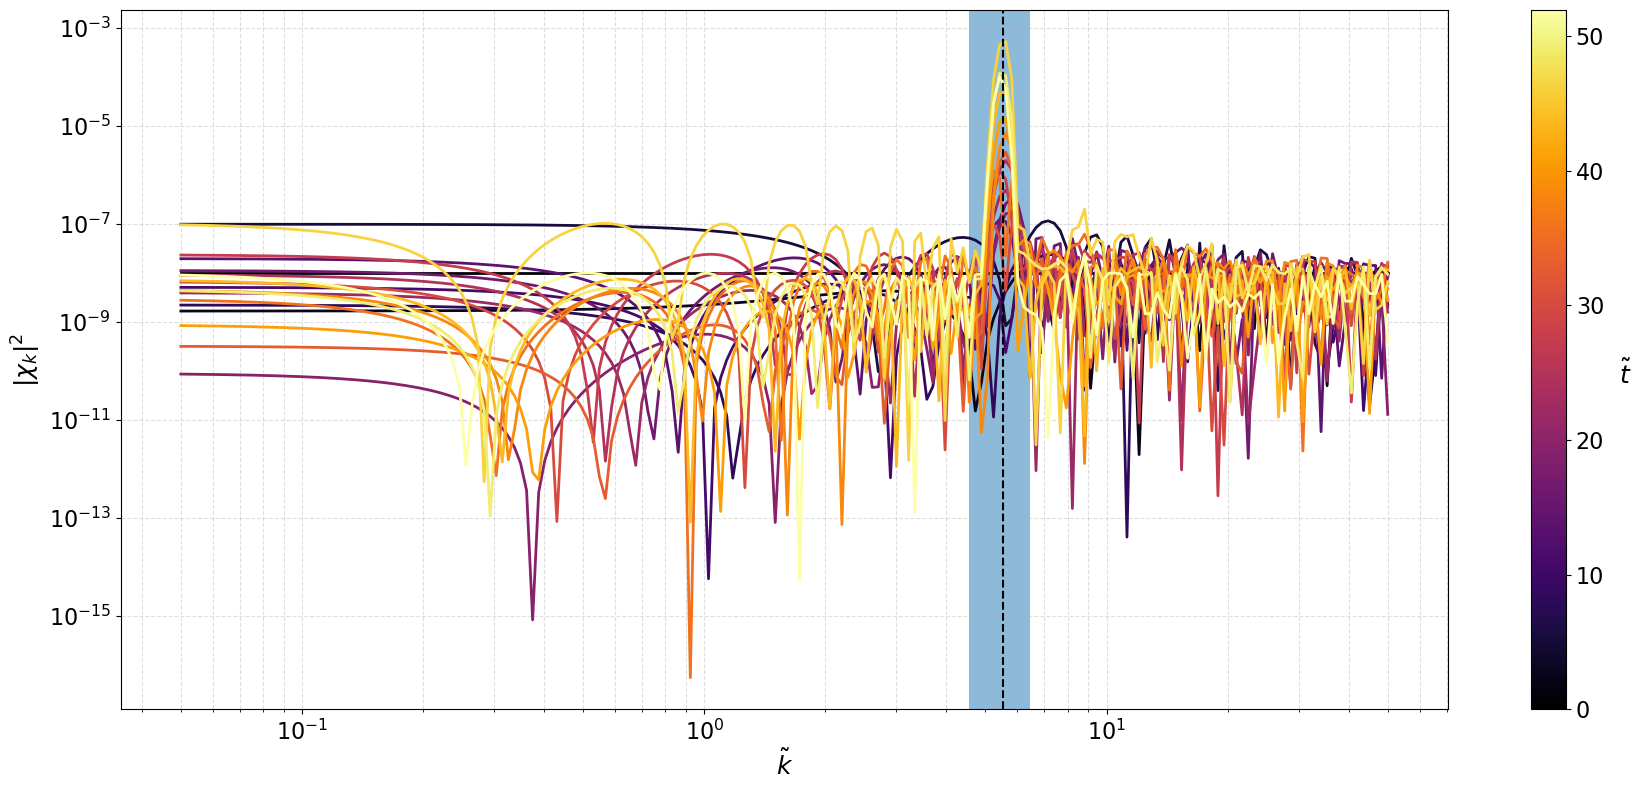

In [ ]:
# =============================================================================
# Plot chi mode spectra at several times
# =============================================================================

Nt_plot     = 20
idx_plot    = np.linspace(0, Nt - 1, Nt_plot, dtype=int)
t_plot_arr  = times[idx_plot]

Kmax =  6.4686076615463275
Deltak = 0.9550688389085353

fig, ax = plt.subplots(figsize=(18, 8))
cmap = plt.cm.inferno
norm = plt.Normalize(t_plot_arr.min(), t_plot_arr.max())

for it in idx_plot:
    ax.loglog(k_modes, np.abs(sol_chi_k[:, it])**2,
              color=cmap(norm(times[it])), lw=2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\tilde{t}$', fontsize = 18, rotation = 0, labelpad = 15)
cbar.set_ticks(np.linspace(0, 50, 6))
cbar.ax.tick_params(labelsize=16)
ax.set_xlabel(r'$\tilde{k}$', fontsize = 18)
ax.tick_params(labelsize=16)
ax.set_ylabel(r'$|\chi_k|^2$', fontsize = 18)
ax.grid(True, which='both', ls='--', alpha=0.4)
ax.axvspan(Kmax - 2*Deltak, Kmax, alpha = 0.5)
ax.axvline(Kmax-Deltak, ls = "--", color = "black")
plt.tight_layout()
plt.savefig("Pchi_lineal.pdf", format = "pdf")
#plt.show()


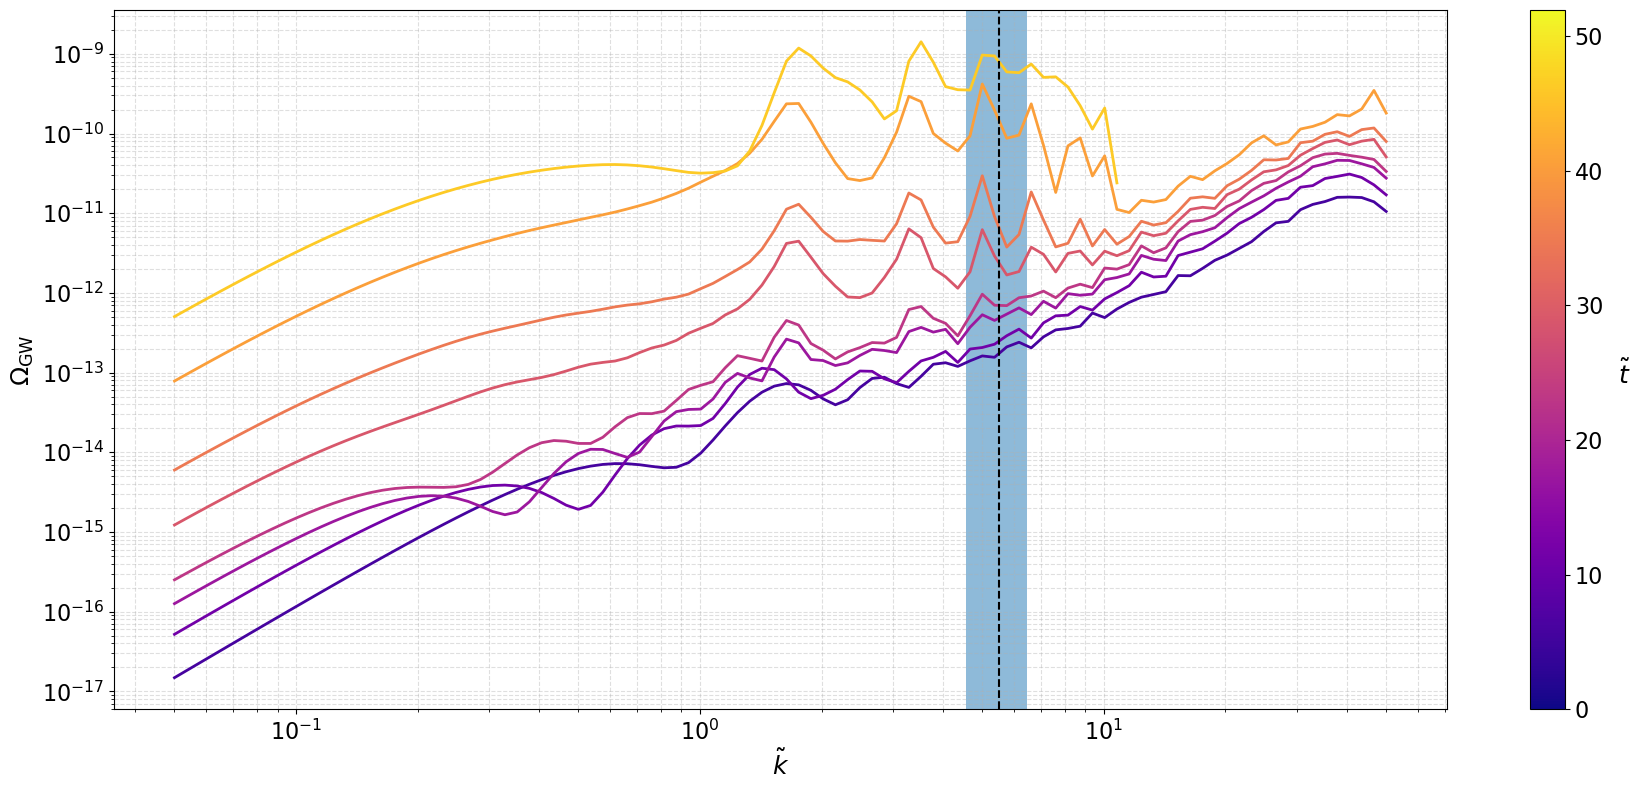

In [21]:

# =============================================================================
# Plot GW spectra
# =============================================================================

fig, ax = plt.subplots(figsize=(18, 8))
cmap = plt.cm.plasma
norm = plt.Normalize(t_plot_gw_arr.min(), t_plot_gw_arr.max())

for it, t_gw in enumerate(t_plot_gw_arr):
    y = Omega_GW_arr[:, it]
    # Avoid log of zero
    if y.max() > 0:
        ax.loglog(k_gw, np.where(y > 0, y, np.nan),
                  color=cmap(norm(t_gw)), lw=2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\tilde{t}$', fontsize = 18, rotation = 0, labelpad = 15)
cbar.set_ticks(np.linspace(0, 50, 6))
cbar.ax.tick_params(labelsize=16)
ax.set_xlabel(r'$\tilde{k}$', fontsize = 18)
ax.tick_params(labelsize=16)
ax.set_ylabel(r'$\Omega_{\text{GW}}$', fontsize = 18)
ax.grid(True, which='both', ls='--', alpha=0.4)
ax.axvspan(Kmax - 2*Deltak, Kmax, alpha = 0.5)
ax.axvline(Kmax-Deltak, ls = "--", color = "black")
plt.tight_layout()
plt.savefig("Omega_lineal.pdf", format = "pdf")